In [1]:
# ============================================================
# CARDIOVISION AI — RETINAL VESSEL ANALYSIS
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import cv2

print("Retinal vessel analysis environment ready.")

Retinal vessel analysis environment ready.


Patient ID: 2491006
Image path: ../data/raw/china_fundus_cimt/Fundus_CIMT_2903 Dataset/2491006_R.png
Image size: (512, 512)


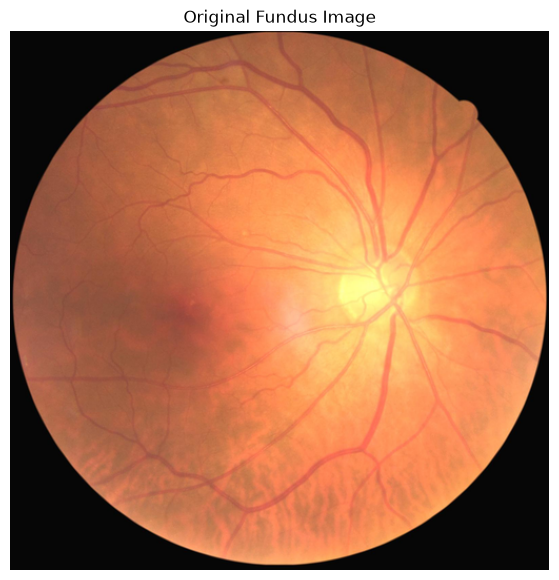

In [2]:
# ============================================================
# LOAD FUNDUS IMAGE
# ============================================================

DATASET_DIR = Path(
    "../data/raw/china_fundus_cimt/"
    "Fundus_CIMT_2903 Dataset"
)

# Use the same patient/sample approach as before
with open(DATASET_DIR / "data_info.json", "r") as f:
    metadata = json.load(f)

patient_id = list(metadata.keys())[0]
patient_info = metadata[patient_id]

image_path = DATASET_DIR / patient_info["right_eye"]

image = Image.open(image_path).convert("RGB")

print("Patient ID:", patient_id)
print("Image path:", image_path)
print("Image size:", image.size)

plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.axis("off")
plt.title("Original Fundus Image")
plt.show()

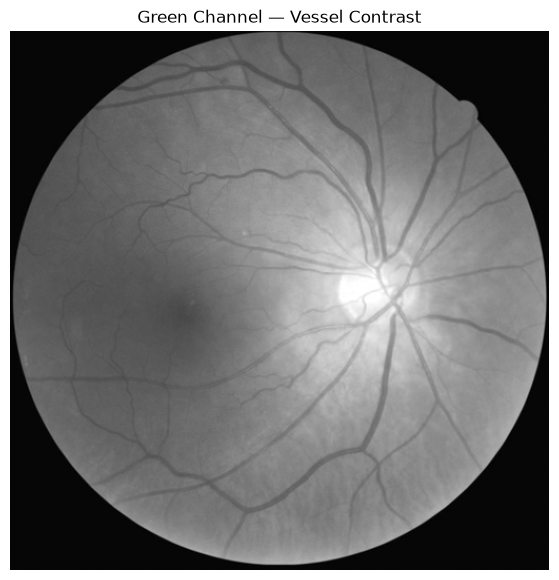

In [3]:
# ============================================================
# GREEN CHANNEL EXTRACTION
# ============================================================

image_np = np.array(image)

green_channel = image_np[:, :, 1]

plt.figure(figsize=(7, 7))
plt.imshow(green_channel, cmap="gray")
plt.axis("off")
plt.title("Green Channel — Vessel Contrast")
plt.show()

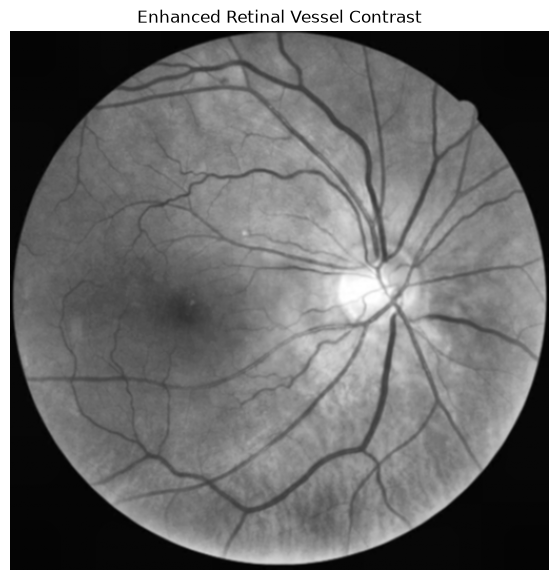

In [4]:
# ============================================================
# VESSEL CONTRAST ENHANCEMENT
# ============================================================

# Convert green channel to uint8
green_uint8 = green_channel.astype(np.uint8)

# CLAHE for local contrast enhancement
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced_green = clahe.apply(green_uint8)

# Light Gaussian smoothing
enhanced_green = cv2.GaussianBlur(
    enhanced_green,
    (3, 3),
    0
)

# Display
plt.figure(figsize=(7, 7))
plt.imshow(enhanced_green, cmap="gray")
plt.axis("off")
plt.title("Enhanced Retinal Vessel Contrast")
plt.show()

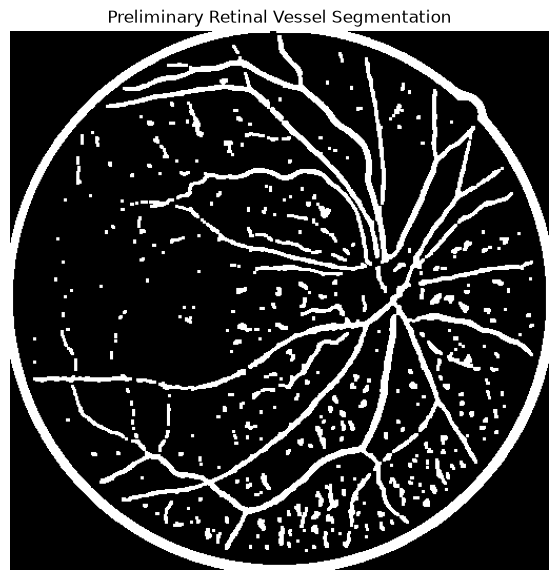

In [5]:
# ============================================================
# PRELIMINARY RETINAL VESSEL SEGMENTATION
# ============================================================

# Adaptive thresholding
vessel_mask = cv2.adaptiveThreshold(
    enhanced_green,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    5
)

# Remove small noise
kernel = np.ones((3, 3), np.uint8)

vessel_mask = cv2.morphologyEx(
    vessel_mask,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

# Display
plt.figure(figsize=(7, 7))
plt.imshow(vessel_mask, cmap="gray")
plt.axis("off")
plt.title("Preliminary Retinal Vessel Segmentation")
plt.show()

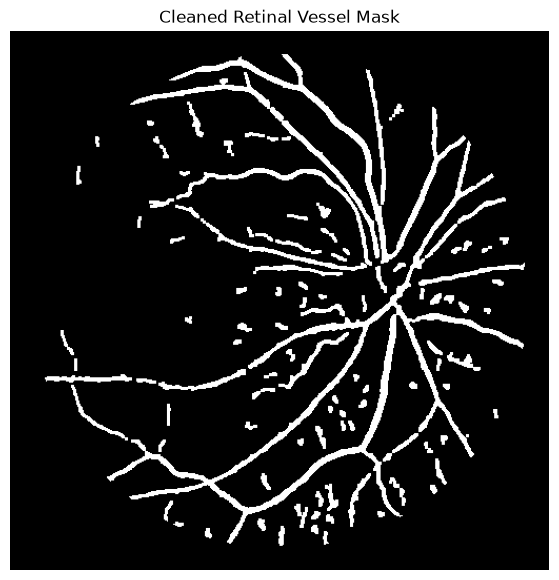

In [6]:
# ============================================================
# CLEAN RETINAL VESSEL MASK
# ============================================================

# Create a circular retinal field mask
h, w = vessel_mask.shape

field_mask = np.zeros((h, w), dtype=np.uint8)

center = (w // 2, h // 2)
radius = int(min(h, w) * 0.46)

cv2.circle(
    field_mask,
    center,
    radius,
    255,
    -1
)

# Keep only pixels inside the retinal field
clean_mask = cv2.bitwise_and(
    vessel_mask,
    field_mask
)

# Remove small connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    clean_mask,
    connectivity=8
)

min_area = 30

filtered_mask = np.zeros_like(clean_mask)

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]

    if area >= min_area:
        filtered_mask[labels == i] = 255

# Display cleaned mask
plt.figure(figsize=(7, 7))
plt.imshow(filtered_mask, cmap="gray")
plt.axis("off")
plt.title("Cleaned Retinal Vessel Mask")
plt.show()

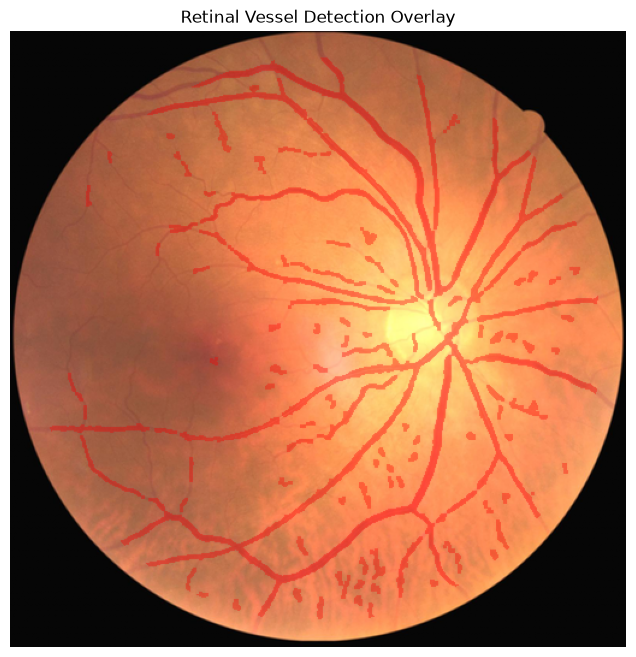

In [7]:
# ============================================================
# VESSEL MAP OVERLAY
# ============================================================

# Normalize images
fundus_display = np.array(image.resize(
    (filtered_mask.shape[1], filtered_mask.shape[0])
)) / 255.0

# Create RGB vessel layer
vessel_overlay = fundus_display.copy()

# Highlight detected vessels
vessel_pixels = filtered_mask > 0

vessel_overlay[vessel_pixels] = [
    1.0, 0.0, 0.0
]

# Blend original + vessel map
overlay = (
    0.65 * fundus_display +
    0.35 * vessel_overlay
)

overlay = np.clip(overlay, 0, 1)

# Display
plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title("Retinal Vessel Detection Overlay")
plt.show()

In [8]:
# ============================================================
# QUANTITATIVE RETINAL VASCULAR FEATURES
# ============================================================

# Total pixels inside retinal field
retinal_area = np.sum(field_mask > 0)

# Detected vessel pixels
vessel_pixels = np.sum(filtered_mask > 0)

# Vessel density / coverage
vessel_density = vessel_pixels / retinal_area

# Total detected vessel area
vessel_area = vessel_pixels

print("=" * 55)
print("RETINAL VASCULAR FEATURES")
print("=" * 55)

print(f"Retinal Area       : {retinal_area:,} pixels")
print(f"Vessel Pixels      : {vessel_area:,} pixels")
print(f"Vessel Density     : {vessel_density:.4f}")
print(f"Vessel Density (%) : {vessel_density * 100:.2f}%")

RETINAL VASCULAR FEATURES
Retinal Area       : 173,485 pixels
Vessel Pixels      : 23,109 pixels
Vessel Density     : 0.1332
Vessel Density (%) : 13.32%


RETINAL VESSEL SKELETON
Skeleton Pixels : 4,603


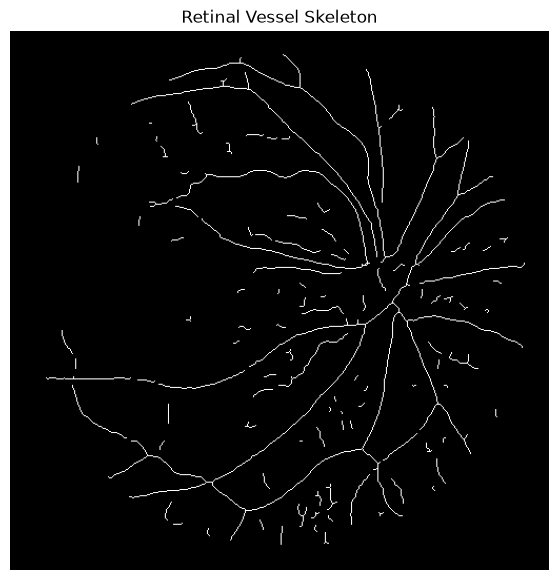

In [10]:
# ============================================================
# RETINAL VESSEL SKELETONIZATION
# ============================================================

from skimage.morphology import skeletonize

# Convert mask to binary
binary_vessels = filtered_mask > 0

# Skeletonize
skeleton = skeletonize(binary_vessels)

# Count skeleton pixels
skeleton_length = np.sum(skeleton)

print("=" * 55)
print("RETINAL VESSEL SKELETON")
print("=" * 55)

print(f"Skeleton Pixels : {skeleton_length:,}")

# Display skeleton
plt.figure(figsize=(7, 7))
plt.imshow(skeleton, cmap="gray")
plt.axis("off")
plt.title("Retinal Vessel Skeleton")
plt.show()

In [11]:
# ============================================================
# VASCULAR STRUCTURAL FEATURES
# ============================================================

# Convert skeleton to binary
skeleton_binary = skeleton.astype(np.uint8)

# Count neighboring skeleton pixels for every pixel
kernel = np.array([
    [1, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
], dtype=np.uint8)

neighbor_count = cv2.filter2D(
    skeleton_binary,
    -1,
    kernel
)

# Skeleton pixels
skeleton_pixels = skeleton_binary.sum()

# Endpoints: exactly 1 neighboring vessel pixel
endpoints = np.logical_and(
    skeleton_binary == 1,
    neighbor_count == 1
)

# Branch points: 3 or more neighboring vessel pixels
branch_points = np.logical_and(
    skeleton_binary == 1,
    neighbor_count >= 3
)

endpoint_count = endpoints.sum()
branch_point_count = branch_points.sum()

# Structural ratios
branch_density = branch_point_count / retinal_area
skeleton_density = skeleton_pixels / retinal_area

print("=" * 60)
print("RETINAL VASCULAR STRUCTURAL FEATURES")
print("=" * 60)

print(f"Vessel Pixel Count     : {vessel_area:,}")
print(f"Skeleton Pixel Count   : {skeleton_pixels:,}")
print(f"Endpoint Count         : {endpoint_count:,}")
print(f"Branch Point Count     : {branch_point_count:,}")
print(f"Vessel Density         : {vessel_density:.4f}")
print(f"Skeleton Density       : {skeleton_density:.4f}")
print(f"Branch Point Density   : {branch_density:.6f}")

RETINAL VASCULAR STRUCTURAL FEATURES
Vessel Pixel Count     : 23,109
Skeleton Pixel Count   : 4,603
Endpoint Count         : 256
Branch Point Count     : 168
Vessel Density         : 0.1332
Skeleton Density       : 0.0265
Branch Point Density   : 0.000968


In [12]:
# ============================================================
# REUSABLE VASCULAR FEATURE EXTRACTION
# ============================================================

def extract_vascular_features(image):
    """
    Extract basic retinal vascular features from a fundus image.
    """

    image_np = np.array(image)

    # Green channel
    green = image_np[:, :, 1]

    # CLAHE enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(green)

    # Gaussian smoothing
    enhanced = cv2.GaussianBlur(
        enhanced,
        (3, 3),
        0
    )

    # Adaptive vessel segmentation
    mask = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        5
    )

    # Retinal field mask
    h, w = mask.shape

    field = np.zeros((h, w), dtype=np.uint8)

    center = (w // 2, h // 2)
    radius = int(min(h, w) * 0.46)

    cv2.circle(
        field,
        center,
        radius,
        255,
        -1
    )

    mask = cv2.bitwise_and(
        mask,
        field
    )

    # Remove small components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    cleaned = np.zeros_like(mask)

    for i in range(1, num_labels):

        area = stats[i, cv2.CC_STAT_AREA]

        if area >= 30:
            cleaned[labels == i] = 255

    # Vessel density
    retinal_area = np.sum(field > 0)
    vessel_pixels = np.sum(cleaned > 0)

    vessel_density = vessel_pixels / retinal_area

    # Skeleton
    skeleton = skeletonize(cleaned > 0)

    skeleton_pixels = skeleton.sum()

    # Neighbour analysis
    skeleton_uint8 = skeleton.astype(np.uint8)

    kernel = np.array([
        [1, 1, 1],
        [1, 0, 1],
        [1, 1, 1]
    ], dtype=np.uint8)

    neighbors = cv2.filter2D(
        skeleton_uint8,
        -1,
        kernel
    )

    endpoints = np.logical_and(
        skeleton_uint8 == 1,
        neighbors == 1
    )

    branch_points = np.logical_and(
        skeleton_uint8 == 1,
        neighbors >= 3
    )

    endpoint_count = endpoints.sum()
    branch_point_count = branch_points.sum()

    return {
        "vessel_density": vessel_density,
        "vessel_pixels": int(vessel_pixels),
        "skeleton_pixels": int(skeleton_pixels),
        "endpoint_count": int(endpoint_count),
        "branch_point_count": int(branch_point_count),
        "skeleton_density": skeleton_pixels / retinal_area,
        "branch_point_density": branch_point_count / retinal_area
    }


# Test the function
features = extract_vascular_features(image)

print("=" * 60)
print("EXTRACTED VASCULAR FEATURE VECTOR")
print("=" * 60)

for name, value in features.items():
    print(f"{name:25s}: {value:.6f}")

EXTRACTED VASCULAR FEATURE VECTOR
vessel_density           : 0.168954
vessel_pixels            : 29311.000000
skeleton_pixels          : 7142.000000
endpoint_count           : 402.000000
branch_point_count       : 640.000000
skeleton_density         : 0.041168
branch_point_density     : 0.003689


In [2]:
# ============================================================
# CREATE TEST DATASET FOR VASCULAR ANALYSIS
# ============================================================

from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm

# Dataset directory
DATASET_DIR = Path(
    "../data/raw/china_fundus_cimt/Fundus_CIMT_2903 Dataset"
)

print("Dataset directory:")
print(DATASET_DIR.resolve())

Dataset directory:
/Users/shimantranjan/cardiovision-ai/data/raw/china_fundus_cimt/Fundus_CIMT_2903 Dataset


In [3]:
# ============================================================
# RECREATE TEST SPLIT
# ============================================================

import json
from sklearn.model_selection import train_test_split

# Load metadata
metadata_path = DATASET_DIR / "data_info.json"

with open(metadata_path, "r") as f:
    metadata = json.load(f)

# Convert metadata to DataFrame
records = []

for patient_id, info in metadata.items():

    records.append({
        "patient_id": patient_id,
        "label": int(info["label"])
    })

metadata_df = pd.DataFrame(records)

print("Total patients:", len(metadata_df))
print("\nClass distribution:")
print(metadata_df["label"].value_counts())

# Same patient-level split strategy
train_df, temp_df = train_test_split(
    metadata_df,
    test_size=0.20,
    stratify=metadata_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTest class distribution:")
print(test_df["label"].value_counts())

Total patients: 2903

Class distribution:
label
1    2054
0     849
Name: count, dtype: int64

Split sizes:
Train: 2322
Validation: 290
Test: 291

Test class distribution:
label
1    206
0     85
Name: count, dtype: int64


In [4]:
# ============================================================
# LOAD TEST IMAGES FOR VASCULAR ANALYSIS
# ============================================================

image_files = list(DATASET_DIR.rglob("*.jpg")) + list(DATASET_DIR.rglob("*.png"))

print("Total image files found:", len(image_files))

# Create patient ID → image mapping
image_map = {}

for img_path in image_files:
    patient_id = img_path.stem.split("_")[0]
    image_map.setdefault(patient_id, []).append(img_path)

# Find test patients that have images
test_image_records = []

for _, row in test_df.iterrows():
    patient_id = row["patient_id"]

    if patient_id in image_map:
        test_image_records.append({
            "patient_id": patient_id,
            "label": row["label"],
            "image_path": image_map[patient_id][0]
        })

test_images_df = pd.DataFrame(test_image_records)

print("\nTest patients with images:", len(test_images_df))
print("\nClass distribution:")
print(test_images_df["label"].value_counts())

display(test_images_df.head())

Total image files found: 5806

Test patients with images: 291

Class distribution:
label
1    206
0     85
Name: count, dtype: int64


,patient_id,label,image_path
0,428263004,1,../data/raw/china_fundus_cimt/Fundus_CIMT_2903...
1,146490006,1,../data/raw/china_fundus_cimt/Fundus_CIMT_2903...
2,274264004,1,../data/raw/china_fundus_cimt/Fundus_CIMT_2903...
3,563019001,1,../data/raw/china_fundus_cimt/Fundus_CIMT_2903...
4,349121001,1,../data/raw/china_fundus_cimt/Fundus_CIMT_2903...


In [6]:
# ============================================================
# VASCULAR FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_vascular_features(image):

    # Convert BGR → RGB
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Green channel gives better retinal vessel contrast
    green = rgb[:, :, 1]

    # Normalize
    green = cv2.normalize(
        green, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Improve contrast
    enhanced = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    ).apply(green)

    # Threshold for preliminary vessel detection
    _, vessel_mask = cv2.threshold(
        enhanced,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Remove small noise
    kernel = np.ones((3, 3), np.uint8)

    vessel_mask = cv2.morphologyEx(
        vessel_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # Retinal area
    retinal_area = np.sum(green > 5)

    # Vessel pixels
    vessel_pixels = np.sum(vessel_mask > 0)

    # Vessel density
    vessel_density = (
        vessel_pixels / retinal_area
        if retinal_area > 0 else 0
    )

    # Skeletonization
    from skimage.morphology import skeletonize

    skeleton = skeletonize(vessel_mask > 0)

    skeleton_pixels = np.sum(skeleton)

    skeleton_density = (
        skeleton_pixels / retinal_area
        if retinal_area > 0 else 0
    )

    # Count skeleton endpoints
    skeleton_uint8 = skeleton.astype(np.uint8)

    neighbor_count = cv2.filter2D(
        skeleton_uint8,
        -1,
        np.ones((3, 3), np.uint8)
    )

    endpoint_mask = (
        skeleton &
        (neighbor_count == 2)
    )

    endpoint_count = np.sum(endpoint_mask)

    # Count branch points
    branch_mask = (
        skeleton &
        (neighbor_count >= 4)
    )

    branch_point_count = np.sum(branch_mask)

    branch_point_density = (
        branch_point_count / retinal_area
        if retinal_area > 0 else 0
    )

    return {
        "vessel_density": vessel_density,
        "vessel_pixels": vessel_pixels,
        "skeleton_pixels": skeleton_pixels,
        "endpoint_count": endpoint_count,
        "branch_point_count": branch_point_count,
        "skeleton_density": skeleton_density,
        "branch_point_density": branch_point_density
    }


print("Vascular feature extraction function loaded successfully.")

Vascular feature extraction function loaded successfully.


In [7]:
# ============================================================
# EXTRACT VASCULAR FEATURES FOR ALL TEST PATIENTS
# ============================================================

vascular_results = []

for idx, row in tqdm(
    test_images_df.iterrows(),
    total=len(test_images_df)
):
    image_path = row["image_path"]

    # Read fundus image
    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Could not read: {image_path}")
        continue

    # Extract vascular features
    features = extract_vascular_features(image)

    # Add patient information
    features["patient_id"] = row["patient_id"]
    features["label"] = row["label"]

    vascular_results.append(features)

# Convert results to DataFrame
vascular_df = pd.DataFrame(vascular_results)

print("=" * 60)
print("VASCULAR FEATURE EXTRACTION COMPLETE")
print("=" * 60)

print(f"Patients processed: {len(vascular_df)}")
print(f"Features extracted: {len(vascular_df.columns)}")

display(vascular_df.head())

100%|██████████| 291/291 [00:03<00:00, 75.29it/s]

VASCULAR FEATURE EXTRACTION COMPLETE
Patients processed: 291
Features extracted: 9


,vessel_density,vessel_pixels,skeleton_pixels,endpoint_count,branch_point_count,skeleton_density,branch_point_density,patient_id,label
0,0.301736,61257,1863,47,7,0.009177,0.000034,428263004,1
1,0.235015,61292,1910,23,18,0.007324,0.000069,146490006,1
2,0.309365,63460,2554,143,90,0.012451,0.000439,274264004,1
3,0.294541,60340,1745,0,4,0.008518,0.000020,563019001,1
4,0.282651,73533,2229,55,46,0.008568,0.000177,349121001,1


In [8]:
# ============================================================
# COMPARE VASCULAR FEATURES: NORMAL vs ABNORMAL
# ============================================================

feature_cols = [
    "vessel_density",
    "vessel_pixels",
    "skeleton_pixels",
    "endpoint_count",
    "branch_point_count",
    "skeleton_density",
    "branch_point_density"
]

comparison = vascular_df.groupby("label")[feature_cols].mean()

comparison.index = ["Normal", "Abnormal"]

print("=" * 70)
print("AVERAGE RETINAL VASCULAR FEATURES")
print("=" * 70)

display(comparison)

AVERAGE RETINAL VASCULAR FEATURES


,vessel_density,vessel_pixels,skeleton_pixels,endpoint_count,branch_point_count,skeleton_density,branch_point_density
Normal,0.287574,64176.952941,2522.352941,100.352941,49.752941,0.011296,0.000222
Abnormal,0.283172,62293.995146,2198.179612,72.582524,26.470874,0.010002,0.000120


In [9]:
# ============================================================
# STATISTICAL SIGNIFICANCE OF VASCULAR FEATURES
# ============================================================

from scipy.stats import mannwhitneyu

print("=" * 75)
print("STATISTICAL COMPARISON: NORMAL vs ABNORMAL")
print("=" * 75)

normal = vascular_df[vascular_df["label"] == 0]
abnormal = vascular_df[vascular_df["label"] == 1]

results = []

for feature in feature_cols:

    stat, p_value = mannwhitneyu(
        normal[feature],
        abnormal[feature],
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "Normal Mean": normal[feature].mean(),
        "Abnormal Mean": abnormal[feature].mean(),
        "p-value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

stats_df = pd.DataFrame(results)

display(stats_df)

STATISTICAL COMPARISON: NORMAL vs ABNORMAL


,Feature,Normal Mean,Abnormal Mean,p-value,Significant
0,vessel_density,0.287574,0.283172,9.540075e-02,No
1,vessel_pixels,64176.952941,62293.995146,2.761076e-07,Yes
2,skeleton_pixels,2522.352941,2198.179612,3.541132e-09,Yes
3,endpoint_count,100.352941,72.582524,8.245253e-07,Yes
4,branch_point_count,49.752941,26.470874,1.974224e-07,Yes
5,skeleton_density,0.011296,0.010002,7.347312e-06,Yes
6,branch_point_density,0.000222,0.000120,4.343008e-07,Yes


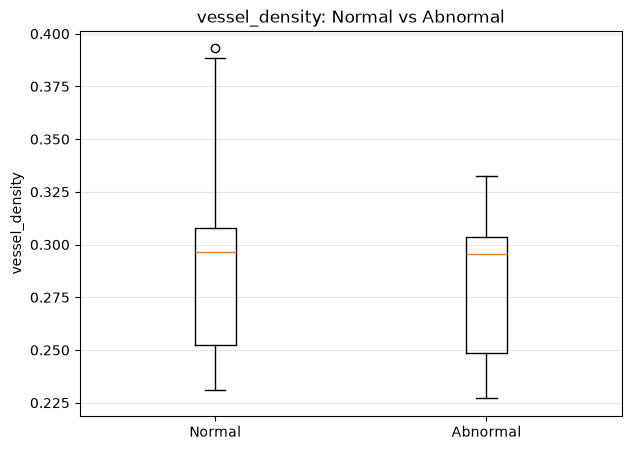

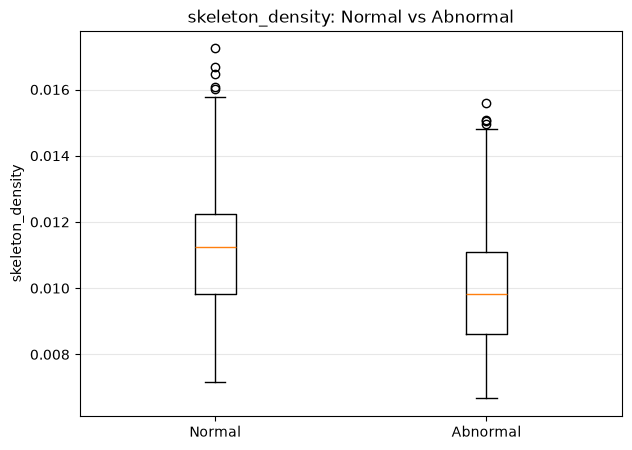

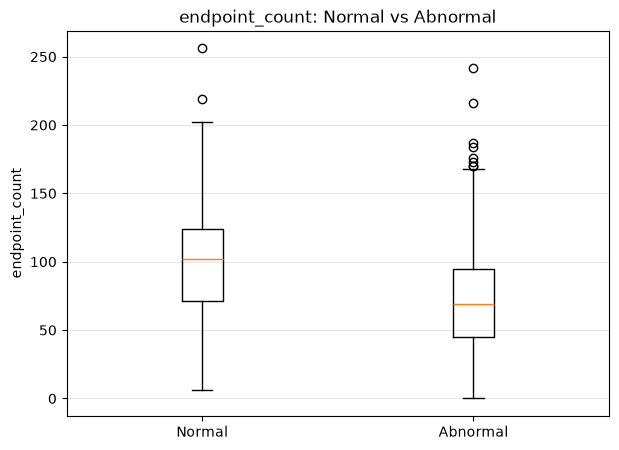

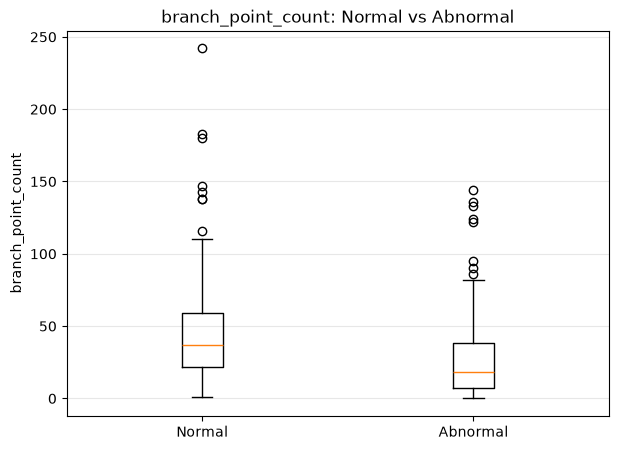

In [11]:
# ============================================================
# VASCULAR FEATURE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plot_features = [
    "vessel_density",
    "skeleton_density",
    "endpoint_count",
    "branch_point_count"
]

for feature in plot_features:

    normal_values = normal[feature].dropna()
    abnormal_values = abnormal[feature].dropna()

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        [normal_values, abnormal_values],
        tick_labels=["Normal", "Abnormal"]
    )

    plt.ylabel(feature)
    plt.title(f"{feature}: Normal vs Abnormal")
    plt.grid(axis="y", alpha=0.3)

    plt.show()

In [12]:
# ============================================================
# FEATURE EFFECT SIZE
# ============================================================

from scipy.stats import mannwhitneyu

features_to_test = [
    "vessel_density",
    "vessel_pixels",
    "skeleton_pixels",
    "endpoint_count",
    "branch_point_count",
    "skeleton_density",
    "branch_point_density"
]

results = []

for feature in features_to_test:
    normal_values = normal[feature].dropna()
    abnormal_values = abnormal[feature].dropna()

    statistic, p_value = mannwhitneyu(
        normal_values,
        abnormal_values,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "Normal Mean": normal_values.mean(),
        "Abnormal Mean": abnormal_values.mean(),
        "Difference": abnormal_values.mean() - normal_values.mean(),
        "p-value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

feature_stats = pd.DataFrame(results)

display(feature_stats.sort_values("p-value"))

,Feature,Normal Mean,Abnormal Mean,Difference,p-value,Significant
2,skeleton_pixels,2522.352941,2198.179612,-324.173330,3.541132e-09,Yes
4,branch_point_count,49.752941,26.470874,-23.282067,1.974224e-07,Yes
1,vessel_pixels,64176.952941,62293.995146,-1882.957796,2.761076e-07,Yes
6,branch_point_density,0.000222,0.000120,-0.000102,4.343008e-07,Yes
3,endpoint_count,100.352941,72.582524,-27.770417,8.245253e-07,Yes
5,skeleton_density,0.011296,0.010002,-0.001294,7.347312e-06,Yes
0,vessel_density,0.287574,0.283172,-0.004403,9.540075e-02,No


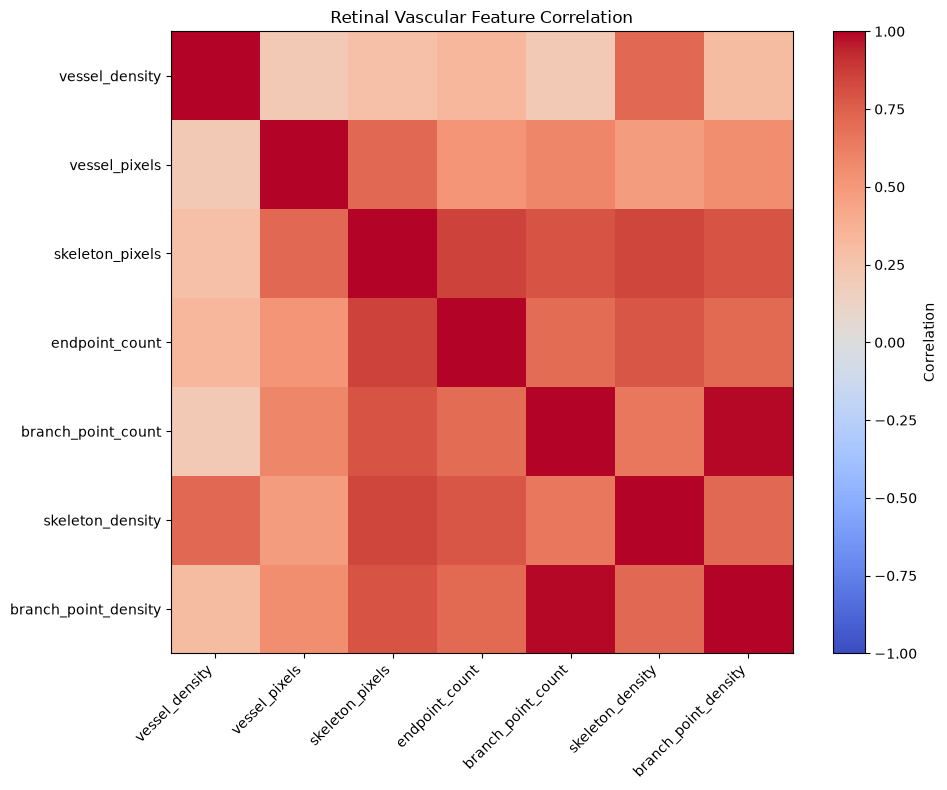

In [13]:
# ============================================================
# VASCULAR FEATURE CORRELATION
# ============================================================

import matplotlib.pyplot as plt

feature_columns = [
    "vessel_density",
    "vessel_pixels",
    "skeleton_pixels",
    "endpoint_count",
    "branch_point_count",
    "skeleton_density",
    "branch_point_density"
]

correlation = vascular_df[feature_columns].corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=45,
    ha="right"
)

plt.yticks(range(len(feature_columns)), feature_columns)

plt.title("Retinal Vascular Feature Correlation")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# EXTRACT VASCULAR FEATURES — TEST SET
# ============================================================

from pathlib import Path
import cv2
import pandas as pd
from tqdm import tqdm

all_results = []

# Search all image files once
image_files = list(DATASET_DIR.rglob("*.jpg")) + list(DATASET_DIR.rglob("*.png"))

print(f"Total images found: {len(image_files)}")

# Map patient ID -> image path
image_map = {}

for path in image_files:
    # Filename begins with patient ID
    patient_id = path.stem.split("_")[0]

    if patient_id not in image_map:
        image_map[patient_id] = path

print(f"Patient IDs mapped: {len(image_map)}")

# Extract features
for _, row in tqdm(
    test_df.iterrows(),
    total=len(test_df),
    desc="Extracting test vascular features"
):

    patient_id = str(row["patient_id"])

    image_path = image_map.get(patient_id)

    if image_path is None:
        continue

    image = cv2.imread(str(image_path))

    if image is None:
        continue

    features = extract_vascular_features(image)

    features["patient_id"] = row["patient_id"]
    features["label"] = row["label"]

    all_results.append(features)

test_vascular_df = pd.DataFrame(all_results)

print("\n" + "=" * 60)
print("TEST VASCULAR FEATURE EXTRACTION COMPLETE")
print("=" * 60)
print(f"Patients processed : {len(test_vascular_df)}")
print(f"Features extracted : {len(test_vascular_df.columns)}")

display(test_vascular_df.head())

Total images found: 5806
Patient IDs mapped: 2903


Extracting test vascular features: 100%|██████████| 291/291 [00:03<00:00, 78.16it/s]


TEST VASCULAR FEATURE EXTRACTION COMPLETE
Patients processed : 291
Features extracted : 9


,vessel_density,vessel_pixels,skeleton_pixels,endpoint_count,branch_point_count,skeleton_density,branch_point_density,patient_id,label
0,0.301736,61257,1863,47,7,0.009177,0.000034,428263004,1
1,0.235015,61292,1910,23,18,0.007324,0.000069,146490006,1
2,0.309365,63460,2554,143,90,0.012451,0.000439,274264004,1
3,0.294541,60340,1745,0,4,0.008518,0.000020,563019001,1
4,0.282651,73533,2229,55,46,0.008568,0.000177,349121001,1


In [15]:
print("Columns in test_df:")
print(test_df.columns.tolist())

print("\nShape:")
print(test_df.shape)

print("\nFirst row:")
display(test_df.head(1))

Columns in test_df:
['patient_id', 'label']

Shape:
(291, 2)

First row:


,patient_id,label
946,428263004,1


In [18]:
# Save extracted test vascular features
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_path = OUTPUT_DIR / "test_vascular_features.csv"
test_vascular_df.to_csv(output_path, index=False)

print("Saved successfully!")
print(f"File: {output_path}")
print(f"Shape: {test_vascular_df.shape}")

Saved successfully!
File: ../data/processed/test_vascular_features.csv
Shape: (291, 9)


In [19]:
# Vascular features → classification experiment

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Features and target
feature_cols = [
    "vessel_density",
    "vessel_pixels",
    "skeleton_pixels",
    "endpoint_count",
    "branch_point_count",
    "skeleton_density",
    "branch_point_density"
]

X = test_vascular_df[feature_cols]
y = test_vascular_df["label"]

# Split vascular-feature data
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Train classifier
vascular_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

vascular_model.fit(X_train, y_train)

# Predictions
y_pred = vascular_model.predict(X_val)
y_prob = vascular_model.predict_proba(X_val)[:, 1]

# Metrics
print("=" * 60)
print("VASCULAR FEATURE CLASSIFIER")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_val, y_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall   : {recall_score(y_val, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

VASCULAR FEATURE CLASSIFIER
Accuracy : 0.7260
Precision: 0.8077
Recall   : 0.8077
F1 Score : 0.8077
ROC-AUC  : 0.7202

Confusion Matrix:
[[11 10]
 [10 42]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.52      0.52        21
           1       0.81      0.81      0.81        52

    accuracy                           0.73        73
   macro avg       0.67      0.67      0.67        73
weighted avg       0.73      0.73      0.73        73

